In [1]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import os
import random
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from torchvision.utils import make_grid
from engression.models import StoNet, StoLayer
from engression.loss_func import energy_loss_two_sample
import argparse
import json
import xarray as xr
import torch.nn as nn
from sklearn.manifold import TSNE
import pca_encoder as pcae


import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import shutil
import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
import utils as ut

In [2]:
settings_file_path = "dpa_train_settings.json"
print("settings_file:", settings_file_path)

with open(settings_file_path, 'r') as file:
        settings = json.load(file)

settings_file: dpa_train_settings.json


FileNotFoundError: [Errno 2] No such file or directory: 'dpa_train_settings.json'

In [ ]:
### Load temperature data ###

# Train
ds = xr.open_dataset(settings['dataset_trefht'])
ds_z500_pre = xr.open_dataset(settings['dataset_z500'])

# Test
ds_test_eth_fact = xr.open_dataset(settings['dataset_trefht_eth_transient'])
ds_test_eth_cf = xr.open_dataset(settings['dataset_trefht_eth_nudged_shifted'])
ds_z500_pre = xr.open_dataset(settings['dataset_z500_eth_test'])

In [ ]:
# set train/test split
ds_train = ds.isel(time=slice(0, 128000)) #4769 * 80
ds_test = ds.isel(time=slice(-64000, 476900))

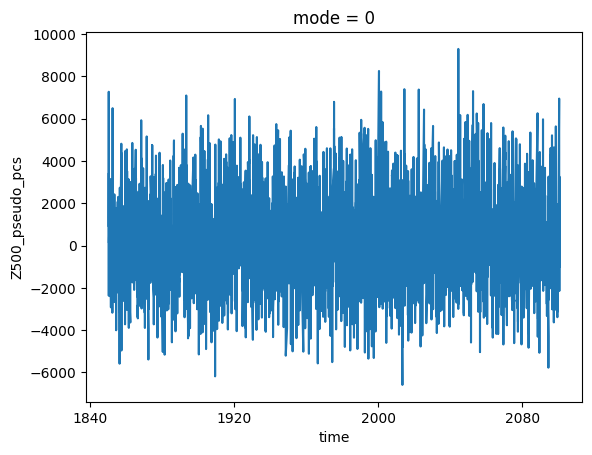

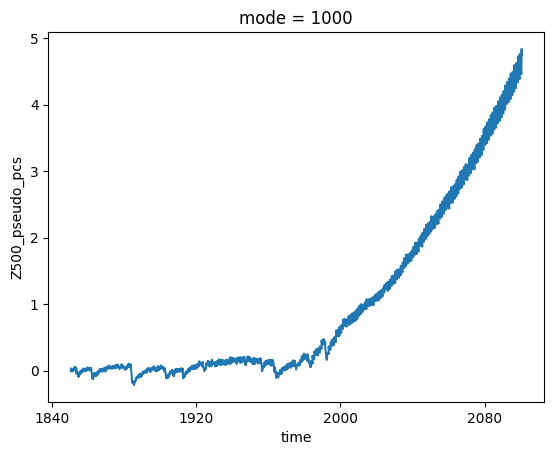

In [14]:
ds_z500_pre.pseudo_pcs.isel(mode=0, time=slice(0,4769)).plot()
plt.show()
ds_z500_pre.pseudo_pcs.isel(mode=1000, time=slice(0,4769)).plot()
plt.show()

In [12]:
ds_z500, _, _ = ut.standardize_numpy(ds_z500_pre.pseudo_pcs.values)
print("z500 shape", ds_z500.shape)
z500 = torch.from_numpy(ds_z500)
print("z500 shape", z500.shape)


z500_train = z500[:int(128000),:]
z500_test = z500[int(-64000):,:]

z500 shape (14307, 1001)
z500 shape torch.Size([14307, 1001])


In [ ]:
# Load temperature data
print("Dataset:", settings['dataset_trefht'])

 #4769 * 80

# transform to torch tensors
x_tr = ut.data_to_torch(ds_train, "TREFHT")
x_te = ut.data_to_torch(ds_test, "TREFHT")

# load Z500
ds_z500_pre = xr.open_dataset(settings['dataset_z500'])


# remove NaNs from data
x_tr_reduced, mask_x_tr = ut.remove_nan_columns(x_tr)
x_te_reduced, mask_x_te = ut.remove_nan_columns(x_te)

# create data loader Temperature
train_dataset = TensorDataset(z500_train, x_tr_reduced)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
print(f"Number of batches: {len(train_loader)}")

# create test loader Temperature
test_dataset = TensorDataset(z500_test, x_te_reduced)
test_loader_in = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print(f"Number of batches: {len(test_loader_in)}")